In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from da_models.goodwin_keen import rhs as rhs_gk

In [2]:
ic_gk = np.load("../data/goodwin_keen_ic.npy")
print(ic_gk)

[0.83605283 0.96861175 0.07019112]


**Simulation**

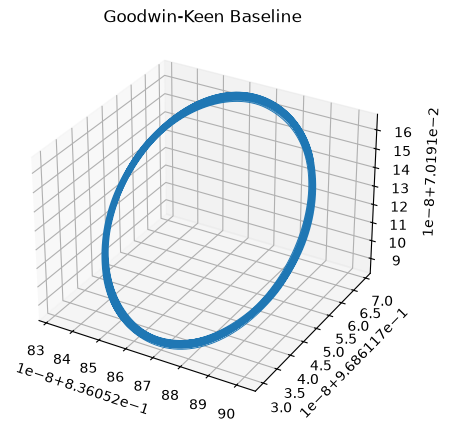

In [3]:
gk_params = dict(alpha=0.025, beta=0.02, delta=0.01, nu=3.0, r=0.03,
                  phi0=0.0400641, phi1=0.0000641026,
                  kappa0=-0.0065, kappa1=np.exp(-5), kappa2=20.0)

t_span = (0, 100)
t_eval = np.linspace(*t_span, 5000)

sol_gk = solve_ivp(
    lambda t, y: rhs_gk(t, y, **gk_params),
    t_span, ic_gk, t_eval=t_eval, rtol=1e-9, atol=1e-9,
)

x1, x2, x3 = sol_gk.y[0], sol_gk.y[1], sol_gk.y[2]

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(projection='3d')
ax.plot(x1, x2, x3, lw=0.7)
ax.set_title('Goodwin-Keen Baseline')
plt.show()

**Perturbation**

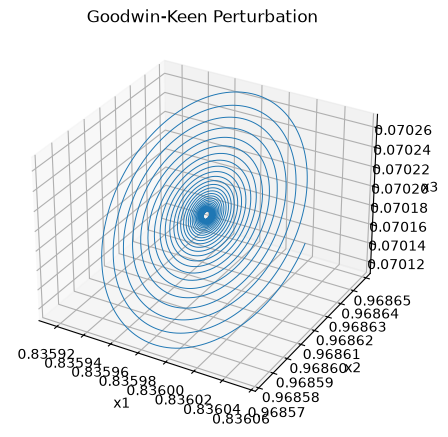

In [4]:
r_new = 0.031
params_tweak_gk = {**gk_params, 'r': r_new}

sol_gk_tweak = solve_ivp(
    lambda t, y: rhs_gk(t, y, **params_tweak_gk),
    t_span, ic_gk, t_eval=t_eval, rtol=1e-9, atol=1e-9,
)

x1_t, x2_t, x3_t = sol_gk_tweak.y[0], sol_gk_tweak.y[1], sol_gk_tweak.y[2]

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(projection='3d')
ax.plot(x1_t, x2_t, x3_t, lw=0.7)
ax.set_xlabel('x1'); ax.set_ylabel('x2'); ax.set_zlabel('x3')
ax.set_title(f'Goodwin-Keen Perturbation')
plt.show()

**Observations**

Changing $r$ by even a tiny amount caused the behavior to go from a limit cycle to an inward spiral.